In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
! pip install optuna

In [74]:
import warnings, gc, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GroupKFold, TimeSeriesSplit

# ========= ユーザー設定（必要に応じて変更） =========
TRAIN_PATH = "/content/drive/MyDrive/AIDLC/MUFG_Competition/train.csv"
TEST_PATH  = "/content/drive/MyDrive/AIDLC/MUFG_Competition/test.csv"

# 確率（連続）提出：解析用。ヘッダあり。
SUB_PATH   = "/content/drive/MyDrive/AIDLC/MUFG_Competition/submit_probs.csv"

# 本番提出（ヘッダ無し・2列: id,label）
LABEL_SUB_PATH  = "/content/drive/MyDrive/AIDLC/MUFG_Competition/submissions/submission_noheader7.csv"
LABEL_THRESHOLD = "auto"  # "auto" か 数値(例 0.5)

# 目的変数/IDの強制指定（自動推定が外れた場合に使用）
FORCE_TARGET = "LoanStatus"   # 例: "LoanStatus" / None
FORCE_ID     = None           # 例: "id" / None

# 学習設定
N_SPLITS = 5
SEED = 42
N_TRIALS = 30
EARLY_STOPPING_ROUNDS = 200
NUM_BOOST_ROUND = 5000

# F1最適化（評価はF1を想定）
THR_METRIC = "f1"  # "f1" or "acc"

# ===== CV strategy (どちらか使う) =====
GROUP_COL = "customer_id"   # 例: 顧客ID列名。無いなら None
TIME_COL  = None            # 例: 申込日等の「時系列カラム」名。使わなければ None



In [40]:
def set_global_seed(seed: int = 42):
    """再現性向上のための乱数固定"""
    import os, random
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_global_seed(SEED)


In [41]:
def guess_id_column(train: pd.DataFrame, test: pd.DataFrame, force_id: str = None):
    """
    ID列の推定:
    - FORCE_ID を最優先
    - 名前優先: 'id'系（完全一致・大小無視）
    - 次にユニーク率>=0.999かつ欠損ゼロの列を採用
    - 一致しない場合は None を返し、後続で連番採番（※推奨は FORCE_ID 明示）
    """
    if force_id is not None:
        if force_id in test.columns:
            return force_id
        raise ValueError(f"FORCE_ID='{force_id}' が test に存在しません。")

    # 名前で優先検出
    lowmap = {c.lower(): c for c in test.columns}
    for key in ["id", "loan_id", "customer_id", "client_id", "userid", "application_id"]:
        if key in lowmap:
            c = lowmap[key]
            # 欠損・重複が無いか軽く見る（無ければ採用）
            if (not test[c].isna().any()) and (test[c].nunique(dropna=True) == len(test)):
                return c

    # 統計的にIDらしい列（高ユニーク率 & 欠損なし）
    candidates = []
    for c in test.columns:
        if test[c].isna().any():
            continue
        nunq = test[c].nunique(dropna=True)
        ratio = nunq / max(1, len(test))
        if ratio >= 0.999:  # ほぼユニーク
            candidates.append((ratio, c))
    candidates.sort(reverse=True)
    if candidates:
        return candidates[0][1]

    return None



def guess_target_column(train: pd.DataFrame, force_target: str = None):
    """
    目的変数の推定（2値分類）
    - 強制指定があればそれを使用
    - よくある名称 / 2値っぽさ から推定
    """
    if force_target is not None:
        if force_target in train.columns:
            return force_target
        else:
            raise ValueError(f"FORCE_TARGET='{force_target}' が train に存在しません。")

    name_candidates = [
        "LoanStatus", "loan_status", "is_default", "default", "Default", "label", "Label", "target", "Target"
    ]
    for c in name_candidates:
        if c in train.columns:
            return c

    # 2値っぽい列を探索（ユニーク数2〜4で、0/1やyes/no系が主）
    for c in train.columns:
        vals = train[c].dropna().unique()
        if 2 <= len(vals) <= 4:
            # 数値0/1 or 文字列2カテゴリあたりを優先
            if np.issubdtype(train[c].dtype, np.number):
                s = set(pd.Series(vals).astype(float).round().tolist())
                if s.issubset({0.0, 1.0}) or len(s) == 2:
                    return c
            else:
                # 文字列なら候補
                return c
    raise ValueError("目的変数の推定に失敗しました。FORCE_TARGET を指定してください。")




In [42]:
def get_cv_splits(X, y, n_splits=5, seed=42, groups=None, time_col=None):
    """
    優先順:
      1) groups がある → GroupKFold
      2) time_col がある → TimeSeriesSplit（time_colでソートしてからsplit）
      3) それ以外 → StratifiedKFold
    返り値は (tr_idx, va_idx) をyieldするイテレータ
    """
    if groups is not None:
        gkf = GroupKFold(n_splits=n_splits)
        yield from gkf.split(X, y, groups=groups)
        return

    if time_col is not None and time_col in X.columns:
        order = np.argsort(X[time_col].values)            # 時系列順に並べ替え
        tss = TimeSeriesSplit(n_splits=n_splits)
        for tr, va in tss.split(order):
            yield order[tr], order[va]
        return

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    yield from skf.split(X, y)

In [43]:
def preprocess_datetime(
    df: pd.DataFrame,
    protected_cols=None,
    verbose=True,
    min_parse_rate=0.6
) -> pd.DataFrame:
    """
    日付/時刻らしい列だけを安全に分解（year/month/day/dow/hour）
    - protected_cols（ID/目的変数）は変更しない
    """
    if protected_cols is None:
        protected_cols = set()
    else:
        protected_cols = set(protected_cols)

    dt_cols = []
    for c in df.columns:
        if c in protected_cols:
            continue
        low = c.lower()
        name_hint = (
            ("date" in low) or ("time" in low) or ("timestamp" in low) or ("datetime" in low)
            or low.endswith("_at") or low in {"created_at", "updated_at", "issued_at"}
        )
        try_parse = name_hint or (df[c].dtype == "object")
        if not try_parse:
            continue
        sample = df[c].dropna().astype(str).head(50)
        if len(sample) == 0:
            continue
        parsed = pd.to_datetime(sample, errors="coerce", utc=False)
        parse_rate = parsed.notna().mean()
        if (name_hint and parse_rate >= 0.3) or (parse_rate >= min_parse_rate):
            dt_cols.append(c)

    if verbose and dt_cols:
        print(f"[INFO] datetime-like columns detected: {dt_cols}")

    for c in dt_cols:
        tmp = pd.to_datetime(df[c], errors="coerce", utc=False)
        df[f"{c}_year"]  = tmp.dt.year
        df[f"{c}_month"] = tmp.dt.month
        df[f"{c}_day"]   = tmp.dt.day
        df[f"{c}_dow"]   = tmp.dt.weekday
        df[f"{c}_hour"]  = tmp.dt.hour
        df.drop(columns=[c], inplace=True)

    return df


def drop_high_cardinality_object(
    df: pd.DataFrame,
    protected_cols=None,
    max_unique_ratio: float = 0.9
) -> pd.DataFrame:
    """
    ほぼユニークな object/category 列（ID的でノイズ）を削除。
    protected_cols は絶対に消さない。
    """
    if protected_cols is None:
        protected_cols = set()
    else:
        protected_cols = set(protected_cols)

    drop_cols = []
    for c in df.columns:
        if c in protected_cols:
            continue
        if (df[c].dtype == "object") or (str(df[c].dtype) == "category"):
            nunq = df[c].nunique(dropna=True)
            ratio = nunq / max(1, len(df))
            if ratio >= max_unique_ratio:
                drop_cols.append(c)
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)
    return df


In [44]:
def _coerce_binary_target(s: pd.Series) -> pd.Series:
    """
    目的変数 Series を 0/1 の int に変換。
    数値2値 / 文字列 yes-no / 2カテゴリ を広く許容。
    """
    if np.issubdtype(s.dtype, np.number):
        vals = np.unique(s.dropna().values)
        if set(vals).issubset({0, 1, 0.0, 1.0}):
            out = s.astype(float)
            if out.isna().any():
                mode_val = int(out.dropna().round().mode().iloc[0])
                out = out.fillna(mode_val)
            return out.round().astype(int)
        if len(vals) == 2:
            lo, hi = float(np.min(vals)), float(np.max(vals))
            mapped = s.map({lo: 0, hi: 1})
            if mapped.isna().any():
                mode_val = int(mapped.dropna().mode().iloc[0])
                mapped = mapped.fillna(mode_val)
            return mapped.astype(int)
        raise ValueError("目的変数が2値と解釈できません（数値）。")

    s_str = s.astype(str).str.strip().str.lower()
    mapping = {
        "1":1, "0":0,
        "y":1, "n":0,
        "yes":1, "no":0,
        "true":1, "false":0,
        "t":1, "f":0,
        "default":1, "non-default":0,
        "defaulter":1, "nondefaulter":0,
        "bad":1, "good":0
    }
    mapped = s_str.map(mapping)
    cover = mapped.notna().mean()
    if cover >= 0.9:
        majority = int(mapped.dropna().mode().iloc[0])
        return mapped.fillna(majority).astype(int)

    uniq = s_str.dropna().unique()
    if len(uniq) == 2:
        cat = pd.Categorical(s_str)
        codes = pd.Series(cat.codes, index=s.index)
        min_code, max_code = codes.min(), codes.max()
        norm = codes.map({min_code: 0, max_code: 1})
        majority = int(norm.dropna().mode().iloc[0])
        return norm.fillna(majority).astype(int)

    raise ValueError("目的変数が2値に解釈できませんでした。FORCE_TARGET を指定してください。")


def best_threshold(y_true, proba, metric="f1"):
    """
    y_true: 0/1 の実ラベル
    proba : 0-1 の予測確率
    戻り値: (best_thr, best_score)
    """
    y_true_np = np.asarray(y_true)
    thr_candidates = np.linspace(0.05, 0.95, 181)  # 0.005刻み
    best_t, best_s = 0.5, -1.0
    for t in thr_candidates:
        y_pred = (proba >= t).astype(int)
        if metric == "f1":
            s = f1_score(y_true_np, y_pred, zero_division=0)
        else:
            s = accuracy_score(y_true_np, y_pred)
        if s > best_s:
            best_s, best_t = s, t
    return float(best_t), float(best_s)


In [82]:
def prepare_data(
    train_path: str,
    test_path: str,
    force_target: str = None,
    force_id: str = None,
    verbose: bool = True
):
    # 読み込み
    train = pd.read_csv(train_path)
    test  = pd.read_csv(test_path)

    # 列推定
    target_col = guess_target_column(train, force_target=force_target)
    id_col_test = guess_id_column(train, test, force_id=force_id)
    id_col_train = id_col_test if (id_col_test in train.columns) else None

    if verbose:
        print(f"[INFO] target_col   = {target_col}")
        print(f"[INFO] id_col_train = {id_col_train}")
        print(f"[INFO] id_col_test  = {id_col_test}")

    # 連結して同一前処理
    train["_is_train"] = 1
    test["_is_train"]  = 0
    all_df = pd.concat([train, test], axis=0, ignore_index=True)

    # === ▼▼▼ ここに特徴量作成処理をまとめる ▼▼▼ ===
    print("[INFO] Preprocessing and creating new features...")

    # 1. BusinessAgeを順序特徴量に変換
    business_age_map = {
        'Startup, Loan Funds will Open Business': 0,
        'New Business or 2 years or less': 1,
        'Existing or more than 2 years old': 2,
        'Change of Ownership': 2, # 既存事業なので2とする
        'Unanswered': 1 # 中間的な値で補完
    }
    all_df['BusinessAge_ordinal'] = all_df['BusinessAge'].map(business_age_map)

    # 2. 2値のカテゴリ変数を0/1に変換
    all_df['CollateralInd'] = all_df['CollateralInd'].map({'Y': 1, 'N': 0})
    all_df['FixedOrVariableInterestInd'] = all_df['FixedOrVariableInterestInd'].map({'V': 1, 'F': 0})

    # 3. 新しい数値特徴量の作成
    # ゼロ除算を避けるために微小な値(1e-6)を加える
    all_df['SBA_Portion'] = all_df['SBAGuaranteedApproval'] / (all_df['GrossApproval'] + 1e-6)
    all_df['Approval_minus_SBA'] = all_df['GrossApproval'] - all_df['SBAGuaranteedApproval']
    all_df['Is_Small_Business_Loan'] = (all_df['GrossApproval'] <= 150000).astype(int)
    all_df['Interest_x_Term'] = all_df['InitialInterestRate'] * all_df['TermInMonths']

    # 4. 新しく作成した特徴量をここにまとめる
    all_df['MonthlyPaymentProxy'] = all_df['GrossApproval'] / (all_df['TermInMonths'] + 1e-6)
    sector_avg_approval = all_df.groupby('NaicsSector')['GrossApproval'].transform('mean')
    all_df['Approval_vs_Sector_Avg'] = all_df['GrossApproval'] / (sector_avg_approval + 1e-6)
    sector_avg_term = all_df.groupby('NaicsSector')['TermInMonths'].transform('mean')
    all_df['Term_vs_Sector_Avg_Diff'] = all_df['TermInMonths'] - sector_avg_term
    """
    特徴量の仮説（一旦コメントアウト)
    # 仮説1: 金利と期間の組み合わせが重要
    all_df['Interest_x_Term'] = all_df['InitialInterestRate'] * all_df['TermInMonths']
    # 仮説2: 金利とSBA保証割合のバランスが重要
    all_df['Interest_div_SBA_Portion'] = all_df['InitialInterestRate'] / (all_df['SBA_Portion'] + 1e-6)
    # 仮説3: 金利と事業歴の組み合わせが重要（新規事業での高金利は特にリスクが高い？）
    # (分母が0にならないように +1 する)
    all_df['Interest_x_BusinessAge'] = all_df['InitialInterestRate'] * (all_df['BusinessAge_ordinal'] + 1)
    # 仮説4: 融資総額あたりの金利（規模に対する金利の高さ）
    all_df['Interest_per_Approval'] = all_df['InitialInterestRate'] / (all_df['GrossApproval'] + 1e-6)
    """

    # --- ▼▼▼ 【新しいアプローチ】相対的な金利特徴量の作成 ▼▼▼ ---
    print("[INFO] Creating relative interest rate features...")

    # グループ化のキーを定義
    group_keys = ['NaicsSector', 'BusinessAge_ordinal']

    # グループごとの平均金利を計算
    group_avg_interest = all_df.groupby(group_keys)['InitialInterestRate'].transform('mean')

    # グループ平均との差と比率を新しい特徴量にする
    all_df['InterestRate_vs_Group_Diff'] = all_df['InitialInterestRate'] - group_avg_interest
    all_df['InterestRate_vs_Group_Ratio'] = all_df['InitialInterestRate'] / (group_avg_interest + 1e-6)

    # --- ▲▲▲ ここまで ▲▲▲ ---

    # 目的変数・ID は保護
    protected_cols = {target_col}
    if id_col_train: protected_cols.add(id_col_train)
    if id_col_test:  protected_cols.add(id_col_test)

    # 日時分解 & 高カーディナリティ除去
    all_df = preprocess_datetime(all_df, protected_cols=protected_cols, verbose=verbose)
    all_df = drop_high_cardinality_object(all_df, protected_cols=protected_cols)

    # object→category
    for c in all_df.columns:
        if c in protected_cols:
            continue
        if all_df[c].dtype == "object":
            all_df[c] = all_df[c].fillna("missing").astype("category")

    # 再分割
    train = all_df[all_df["_is_train"] == 1].drop(columns=["_is_train"])
    test  = all_df[all_df["_is_train"] == 0].drop(columns=["_is_train"])

    # 特徴量
    protected_now = {target_col}
    if id_col_train: protected_now.add(id_col_train)
    feature_cols = [c for c in train.columns if c not in protected_now]
    cat_cols     = [c for c in feature_cols if str(train[c].dtype) in ["category", "bool", "object"]]

    # X, y
    X = train[feature_cols].copy()
    y_raw = train[target_col].copy()
    y = _coerce_binary_target(y_raw).astype(int)

    # 欠損があれば除外
    if y.isna().any():
        bad = int(y.isna().sum())
        print(f"[WARN] 目的変数に欠損: {bad} 行を除外")
        keep = y.notna()
        X = X.loc[keep].reset_index(drop=True)
        y = y.loc[keep].reset_index(drop=True)

    # 提出ID
    if id_col_test is None:
        raise ValueError("[SUBMIT-ERROR] test に ID 列が見つかりません。FORCE_ID を指定してください。")

    test_ids = test[id_col_test].copy()
    if test_ids.isna().any():
        raise ValueError("[SUBMIT-ERROR] test の ID 列に NaN が含まれます。")
    if test_ids.nunique(dropna=True) != len(test_ids):
        raise ValueError("[SUBMIT-ERROR] test の ID 列に重複があります。")

    X_test = test[feature_cols].copy()

    if verbose:
        print(f"[INFO] #features={len(feature_cols)} (cat={len(cat_cols)}, num={len(feature_cols)-len(cat_cols)})")
        vc = y.value_counts(normalize=True).sort_index()
        print(f"[INFO] target distribution: 0 -> {vc.get(0,0):.3f}, 1 -> {vc.get(1,0):.3f}")

    # groups 抽出
    groups = None
    if 'GROUP_COL' in globals() and GROUP_COL is not None:
        if GROUP_COL in train.columns:
            groups = train[GROUP_COL].values
        else:
            print(f"[WARN] GROUP_COL='{GROUP_COL}' が学習データにありません。")

    return X, y, X_test, test_ids, feature_cols, cat_cols, target_col, id_col_test, groups

In [66]:
def optimize_hyperparams(
    X, y, cat_cols,
    n_splits=5,
    seed=42,
    n_trials=50,
    early_stopping_rounds=200,
    num_boost_round=5000,
    groups=None,
    time_col=None
):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    base_pos_weight = neg / max(1, pos)
    print(f"[INFO] class balance: pos={pos}, neg={neg}, base_pos_weight≈{base_pos_weight:.3f}")
    print(f"[INFO] threshold metric = {THR_METRIC}")

    def cv_objective(trial: optuna.trial.Trial):
        params = {
            "objective": "binary", "metric": "auc", "boosting_type": "gbdt", "verbosity": -1,
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 0, 10),
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
            "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
            "max_depth": trial.suggest_int("max_depth", -1, 12),
            "scale_pos_weight": base_pos_weight * trial.suggest_float("pos_weight_mult", 0.5, 4.0),
            "seed": seed, "n_jobs": -1
        }

        cv_iter = get_cv_splits(X, y, n_splits=n_splits, seed=seed, groups=groups, time_col=time_col)
        aucs, metric_scores, best_rounds, thrs = [], [], [], []

        cat_cols_for_te = ['NaicsSector', 'Subprogram', 'BusinessType', 'BusinessAge']
        global_target_mean = y.mean()

        # ▼▼▼ 【エラー修正点①】エンコーディング対象の列を 'object' 型に戻す ▼▼▼
        X_obj = X.copy()
        for col in cat_cols_for_te:
            if col in X_obj.columns:
                X_obj[col] = X_obj[col].astype(object)

        for tr_idx, va_idx in cv_iter:
            X_tr, X_va = X_obj.iloc[tr_idx].copy(), X_obj.iloc[va_idx].copy()
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            # --- ターゲットエンコーディング with スムージング ---
            smoothing_m = 20
            for col in cat_cols_for_te:
                temp_df = pd.DataFrame({col: X_tr[col], 'LoanStatus': y_tr})
                agg = temp_df.groupby(col)['LoanStatus'].agg(['mean', 'count'])
                smoothed_mean = (agg['count'] * agg['mean'] + smoothing_m * global_target_mean) / (agg['count'] + smoothing_m)

                X_tr[f'{col}_te'] = X_tr[col].map(smoothed_mean).fillna(global_target_mean)
                X_va[f'{col}_te'] = X_va[col].map(smoothed_mean).fillna(global_target_mean)

            # ▼▼▼ 【エラー修正点②】TEで使った元の列 *だけ* を削除する ▼▼▼
            X_tr_processed = X_tr.drop(columns=cat_cols_for_te)
            X_va_processed = X_va.drop(columns=cat_cols_for_te)

            # TE対象外のカテゴリ変数をLightGBMに教える
            remaining_cat_cols = [c for c in cat_cols if c not in cat_cols_for_te]

            dtr = lgb.Dataset(X_tr_processed, label=y_tr, categorical_feature=remaining_cat_cols)
            dva = lgb.Dataset(X_va_processed, label=y_va, categorical_feature=remaining_cat_cols)

            model = lgb.train(
                params, dtr, num_boost_round=num_boost_round, valid_sets=[dtr, dva],
                valid_names=["train", "valid"],
                callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False), lgb.log_evaluation(0)]
            )

            p_va = model.predict(X_va_processed, num_iteration=model.best_iteration)
            aucs.append(roc_auc_score(y_va, p_va))

            thr_best, score_best = best_threshold(y_va.values, p_va, metric=THR_METRIC)
            metric_scores.append(score_best)
            best_rounds.append(model.best_iteration)
            thrs.append(thr_best)

        mean_auc = float(np.mean(aucs))
        mean_metric = float(np.mean(metric_scores))
        mean_round = int(np.mean(best_rounds))
        mean_thr = float(np.mean(thrs))

        score = mean_metric if THR_METRIC == "f1" else mean_auc
        trial.set_user_attr("cv_auc", mean_auc)
        trial.set_user_attr("cv_metric", mean_metric)
        trial.set_user_attr("best_round", mean_round)
        trial.set_user_attr("best_thr", mean_thr)
        return score

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(cv_objective, n_trials=n_trials, show_progress_bar=True)

    best = study.best_trial
    best_params = best.params.copy()
    cv_auc = best.user_attrs["cv_auc"]
    cv_metric = best.user_attrs["cv_metric"]
    best_round = best.user_attrs["best_round"]
    best_thr = best.user_attrs["best_thr"]

    print("\n========== Best Trial ==========")
    print(f"AUC (CV mean): {cv_auc:.4f}")
    label_metric = "F1" if THR_METRIC == "f1" else "ACC"
    print(f"{label_metric} (CV mean, tuned thr): {cv_metric:.4f} @thr≈{best_thr:.3f}")
    print(f"best_round≈{best_round}")
    print("best params:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")

    base_pos_weight = (y == 0).sum() / max(1, (y == 1).sum())
    final_params = {
        "objective": "binary", "metric": "auc", "boosting_type": "gbdt",
        "verbosity": -1, "seed": seed, "n_jobs": -1,
        **best_params
    }
    final_params["scale_pos_weight"] = base_pos_weight * final_params.pop("pos_weight_mult")

    return final_params, best_round, best_thr, cv_auc, cv_metric

In [69]:
def train_cv_and_predict(
    X, y, X_test, cat_cols,
    lgb_params,
    best_round,
    n_splits=5,
    seed=42,
    early_stopping_rounds=200,
    groups=None,
    time_col=None
):
    cv_iter = get_cv_splits(X, y, n_splits=n_splits, seed=seed, groups=groups, time_col=time_col)
    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    fold_scores, fold_thrs = [], []

    # ▼▼▼【追加】特徴量重要度を格納するDataFrameを準備 ▼▼▼
    feature_importances = pd.DataFrame(index=X.columns)

    cat_cols_for_te = ['NaicsSector', 'Subprogram', 'BusinessType', 'BusinessAge']
    global_target_mean = y.mean()

    X_obj = X.copy()
    X_test_obj = X_test.copy()
    for col in cat_cols_for_te:
        if col in X_obj.columns:
            X_obj[col] = X_obj[col].astype(object)
            X_test_obj[col] = X_test_obj[col].astype(object)

    print("[INFO] Starting CV with Target Encoding...")
    for fold, (tr_idx, va_idx) in enumerate(cv_iter, 1):
        X_tr, X_va = X_obj.iloc[tr_idx].copy(), X_obj.iloc[va_idx].copy()
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        smoothing_m = 20
        X_test_fold = X_test_obj.copy()

        for col in cat_cols_for_te:
            temp_df = pd.DataFrame({col: X_tr[col], 'LoanStatus': y_tr})
            agg = temp_df.groupby(col)['LoanStatus'].agg(['mean', 'count'])
            smoothed_mean = (agg['count'] * agg['mean'] + smoothing_m * global_target_mean) / (agg['count'] + smoothing_m)

            X_tr[f'{col}_te'] = X_tr[col].map(smoothed_mean).fillna(global_target_mean)
            X_va[f'{col}_te'] = X_va[col].map(smoothed_mean).fillna(global_target_mean)
            X_test_fold[f'{col}_te'] = X_test_fold[col].map(smoothed_mean).fillna(global_target_mean)

        X_tr_processed = X_tr.drop(columns=cat_cols_for_te)
        X_va_processed = X_va.drop(columns=cat_cols_for_te)
        X_test_processed = X_test_fold.drop(columns=cat_cols_for_te)

        remaining_cat_cols = [c for c in cat_cols if c not in cat_cols_for_te]

        dtr = lgb.Dataset(X_tr_processed, label=y_tr, categorical_feature=remaining_cat_cols)
        dva = lgb.Dataset(X_va_processed, label=y_va, categorical_feature=remaining_cat_cols)

        model = lgb.train(
            lgb_params, dtr,
            num_boost_round=max(100, int(best_round * 1.2)),
            valid_sets=[dtr, dva], valid_names=["train", "valid"],
            callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False), lgb.log_evaluation(0)]
        )

        # ▼▼▼【追加】このFoldの重要度を保存 ▼▼▼
        feature_importances[f'fold_{fold}'] = model.feature_importance(importance_type='gain')

        p_va = model.predict(X_va_processed, num_iteration=model.best_iteration)
        oof_pred[va_idx] = p_va

        test_pred += model.predict(X_test_processed, num_iteration=model.best_iteration) / n_splits

        thr_best, score_best = best_threshold(y_va.values, p_va, metric=THR_METRIC)
        fold_scores.append(score_best)
        fold_thrs.append(thr_best)

    oof_auc = roc_auc_score(y, oof_pred)
    global_thr, _ = best_threshold(y.values, oof_pred, metric=THR_METRIC)
    y_oof_pred = (oof_pred >= global_thr).astype(int)
    oof_metric = f1_score(y, y_oof_pred, zero_division=0) if THR_METRIC == "f1" else accuracy_score(y, y_oof_pred)

    label_metric = "F1" if THR_METRIC == "f1" else "ACC"
    print("\n========== CV Summary ==========")
    print(f"OOF AUC: {oof_auc:.4f}")
    print(f"OOF {label_metric} (thr={global_thr:.3f}): {oof_metric:.4f}")
    print(f"Fold {label_metric}s: {[round(s,4) for s in fold_scores]}")

    # ▼▼▼【変更】feature_importancesを返す ▼▼▼
    return test_pred, oof_pred, global_thr, oof_auc, oof_metric, feature_importances

In [48]:
def save_submission(test_ids, preds, path: str, id_col_name: str = "id"):
    """
    確率提出（解析用）：ヘッダあり ['id', 'score']
    """
    out = pd.DataFrame({id_col_name: test_ids, "score": preds})
    out.to_csv(path, index=False)
    print(f"[INFO] probability submission saved to: {path}")


def save_submission_label_noheader(test_ids, preds, path: str, thr: float):
    """
    本番提出: ヘッダ無し2列（id, label）
    - IDは必ず整数 & 欠損/重複なしを厳格チェック
    - ここでNGなら ValueError を出して気づけるようにする
    """
    ids = pd.Series(test_ids).copy()

    # 文字列 "nan" や float NaN を完全排除
    if ids.isna().any():
        na_idx = list(np.where(ids.isna())[0][:5])
        raise ValueError(f"[SUBMIT-ERROR] test_ids に NaN があります（例: 行index {na_idx}）。FORCE_ID を見直してください。")

    # 数値化（小数->整数）を強制。失敗したら明示エラーで止める
    try:
        ids_num = pd.to_numeric(ids, errors="raise")
    except Exception as e:
        raise ValueError(f"[SUBMIT-ERROR] ID を数値化できません。文字列や混在が含まれています。FORCE_ID を正しく指定してください。詳細: {e}")

    # 小数が混じっていたら整数へ（例: 7553.0 -> 7553）
    if (ids_num % 1 != 0).any():
        # 端数が出るのは ID 列推定ミスの可能性大
        bad_idx = list(np.where(ids_num % 1 != 0)[0][:5])
        raise ValueError(f"[SUBMIT-ERROR] 非整数のIDが含まれています（例: 行index {bad_idx}）。ID列の推定が誤っている可能性。FORCE_ID 再設定を。")

    ids_int = ids_num.astype(np.int64)

    # 重複チェック
    dup_mask = ids_int.duplicated(keep=False)
    if dup_mask.any():
        dup_vals = ids_int[dup_mask].unique()[:5]
        raise ValueError(f"[SUBMIT-ERROR] ID の重複があります（例: {dup_vals.tolist()}）。FORCE_ID を再確認してください。")

    # ラベル二値化
    label = (pd.Series(preds) >= float(thr)).astype(int)

    # 出力（※ヘッダ無し）
    out = pd.DataFrame({"id": ids_int, "label": label})
    out.to_csv(path, index=False, header=False)
    print(f"[INFO] headerless label submission saved to: {path} (thr={thr:.3f})")



def save_preview_labels(test_ids, preds, thr: float, id_col_name: str = "id", path: str = None, head: int = 10):
    """
    確率と予測ラベルのプレビュー（ヘッダあり、先頭N件を表示/保存）
    """
    df = pd.DataFrame({
        id_col_name: test_ids,
        "proba": preds,
        "pred_label": (np.asarray(preds) >= float(thr)).astype(int)
    })
    if path:
        df.to_csv(path, index=False)
        print(f"[INFO] preview saved to: {path}")
    display(df.head(head))


In [77]:
def plot_feature_importance(df_importance, top_n=30):
    """特徴量重要度をプロットする"""
    # Fold全体の平均と標準偏差を計算
    df_importance['mean'] = df_importance.mean(axis=1)
    df_importance['std'] = df_importance.std(axis=1)

    # 上位top_n件を抽出してプロット
    plt.figure(figsize=(12, max(6, top_n // 2)))
    sns.barplot(
        x=df_importance.sort_values('mean', ascending=False)['mean'].head(top_n),
        y=df_importance.sort_values('mean', ascending=False).head(top_n).index,
        palette='viridis'
    )
    plt.title(f'Top {top_n} Feature Importances (Gain)')
    plt.xlabel('Mean Importance (Gain)')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig("feature_importance.png") # ファイルに保存
    plt.show()

In [73]:
# この関数を丸ごと置き換えてください
def run_pipeline():
    # データ準備
    X, y, X_test, test_ids, feature_cols, cat_cols, target_col, id_col_for_submit, groups = prepare_data(
        TRAIN_PATH, TEST_PATH, force_target=FORCE_TARGET, force_id=FORCE_ID, verbose=True
    )

    # ハイパラ最適化
    best_params, best_round, best_thr, cv_auc, cv_metric = optimize_hyperparams(
        X, y, cat_cols,
        n_splits=N_SPLITS,
        seed=SEED,
        n_trials=N_TRIALS, # 50などに増やすとより良い
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        num_boost_round=NUM_BOOST_ROUND,
        groups=groups,
        time_col=TIME_COL
    )

    # ▼▼▼【変更】返り値にimportancesを追加 ▼▼▼
    test_pred, oof_pred, global_thr, oof_auc, oof_metric, importances = train_cv_and_predict(
        X, y, X_test, cat_cols,
        lgb_params=best_params,
        best_round=best_round,
        n_splits=N_SPLITS,
        seed=SEED,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        groups=groups,
        time_col=TIME_COL
    )

    # ▼▼▼【追加】特徴量重要度をプロット ▼▼▼
    plot_feature_importance(importances, top_n=30)

    # 保存（確率提出：解析用）
    save_submission(test_ids, test_pred, SUB_PATH, id_col_name=id_col_for_submit)

    # 本番提出（ヘッダ無し）
    thr_to_use = global_thr if (isinstance(LABEL_THRESHOLD, str) and LABEL_THRESHOLD.lower() == "auto") else float(LABEL_THRESHOLD)
    save_submission_label_noheader(test_ids, test_pred, LABEL_SUB_PATH, thr=thr_to_use)

    # プレビュー（任意）
    save_preview_labels(test_ids, test_pred, thr=thr_to_use, id_col_name=id_col_for_submit)

    label_metric = "F1" if THR_METRIC == "f1" else "ACC"
    print("\n========== FINAL ==========")
    print(f"CV(Best) AUC: {cv_auc:.4f}, {label_metric}: {cv_metric:.4f} (thr≈{best_thr:.3f})")
    print(f"OOF      AUC: {oof_auc:.4f}, {label_metric}: {oof_metric:.4f} (thr≈{global_thr:.3f})")
    print(f"[INFO] Submit this (headerless) file: {LABEL_SUB_PATH}")

[I 2025-08-27 03:21:48,163] A new study created in memory with name: no-name-d80e62e1-82fc-40d8-813d-396e9a23bbe4


[INFO] target_col   = LoanStatus
[INFO] id_col_train = id
[INFO] id_col_test  = id
[INFO] Preprocessing and creating new features...
[INFO] Creating interaction features based on InitialInterestRate...
[INFO] #features=25 (cat=4, num=21)
[INFO] target distribution: 0 -> 0.872, 1 -> 0.128
[WARN] GROUP_COL='customer_id' が学習データにありません。
[INFO] class balance: pos=964, neg=6588, base_pos_weight≈6.834
[INFO] threshold metric = f1


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-08-27 03:21:57,026] Trial 0 finished with value: 0.6347404728145128 and parameters: {'learning_rate': 0.042472407130841744, 'num_leaves': 223, 'min_child_samples': 149, 'feature_fraction': 0.8394633936788146, 'bagging_fraction': 0.6624074561769746, 'bagging_freq': 1, 'lambda_l1': 3.3323645788192616e-08, 'lambda_l2': 0.6245760287469893, 'min_split_gain': 0.6011150117432088, 'max_depth': 8, 'pos_weight_mult': 0.5720457300353086}. Best is trial 0 with value: 0.6347404728145128.
[I 2025-08-27 03:22:03,209] Trial 1 finished with value: 0.6277870515808764 and parameters: {'learning_rate': 0.07819459112971966, 'num_leaves': 160, 'min_child_samples': 50, 'feature_fraction': 0.6727299868828402, 'bagging_fraction': 0.6733618039413735, 'bagging_freq': 3, 'lambda_l1': 0.00052821153945323, 'lambda_l2': 7.71800699380605e-05, 'min_split_gain': 0.2912291401980419, 'max_depth': 7, 'pos_weight_mult': 0.9882285122821464}. Best is trial 0 with value: 0.6347404728145128.
[I 2025-08-27 03:22:16,614]

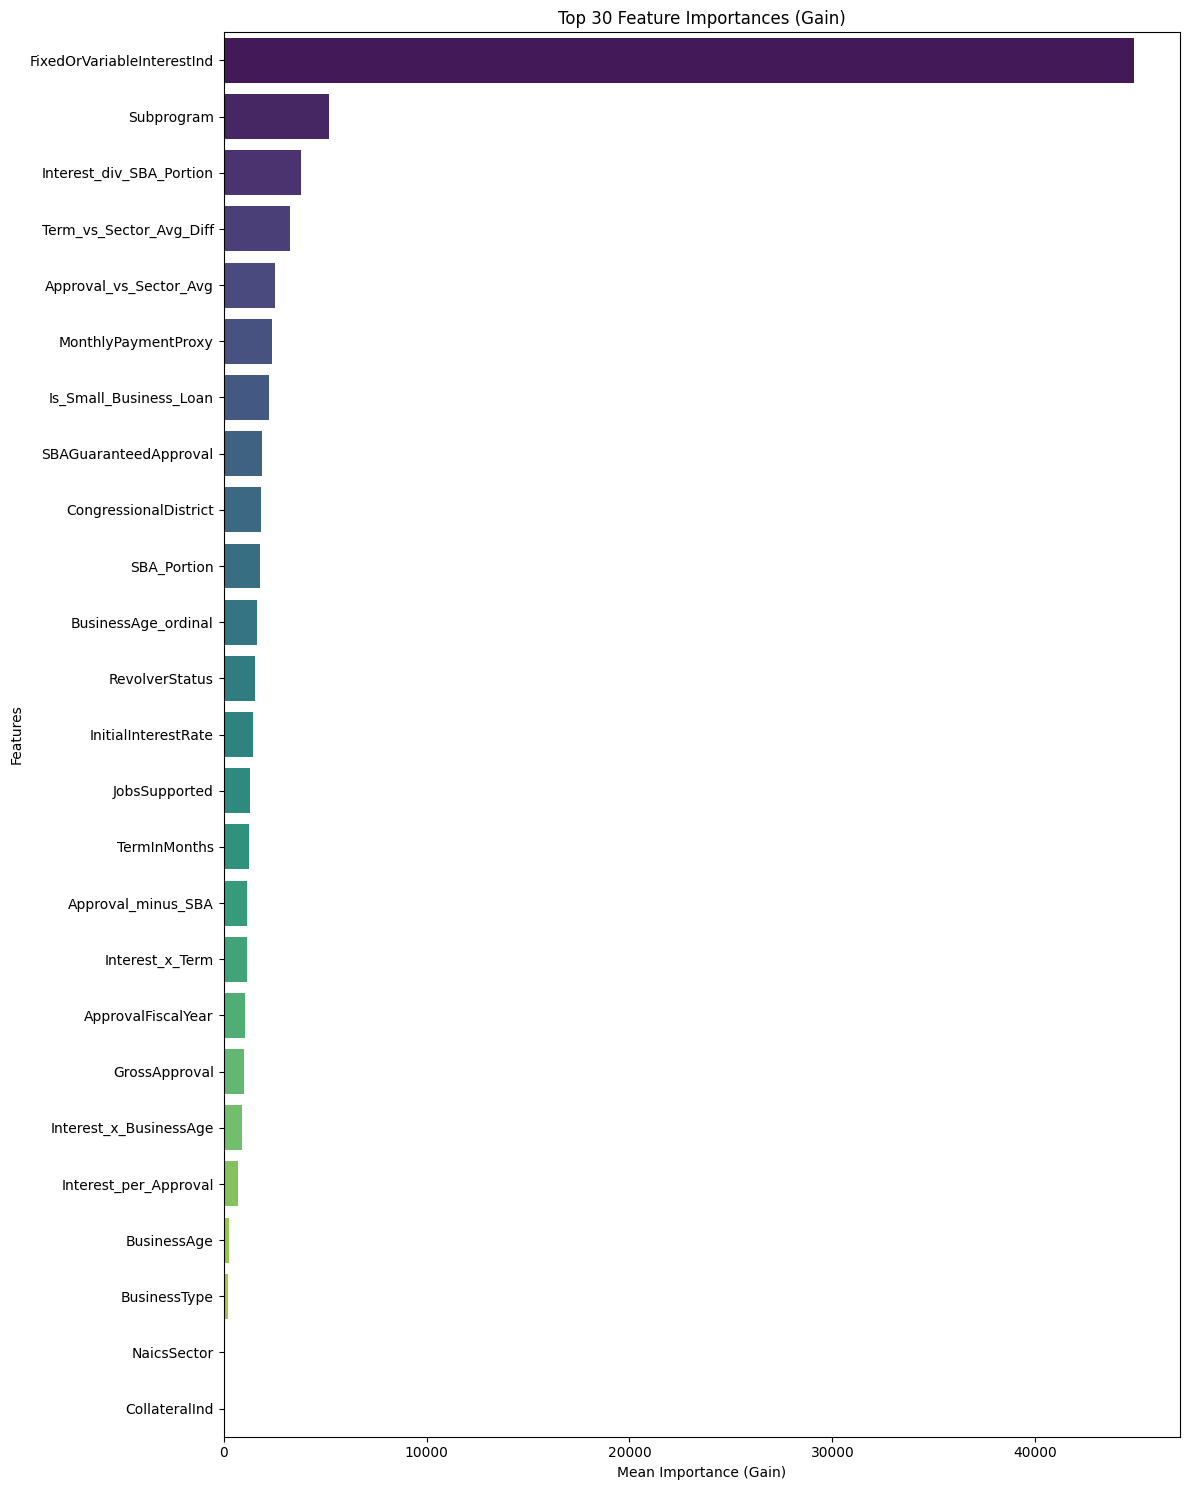

[INFO] probability submission saved to: /content/drive/MyDrive/AIDLC/MUFG_Competition/submit_probs.csv
[INFO] headerless label submission saved to: /content/drive/MyDrive/AIDLC/MUFG_Competition/submissions/submission_noheader7.csv (thr=0.725)


,id,proba,pred_label
7552,7553,0.221194,0
7553,7554,0.015339,0
7554,7555,0.107468,0
7555,7556,0.645157,0
7556,7557,0.707837,0
7557,7558,0.723650,0
7558,7559,0.050073,0
7559,7560,0.070979,0
7560,7561,0.351074,0
7561,7562,0.047743,0



========== FINAL ==========
CV(Best) AUC: 0.9248, F1: 0.6392 (thr≈0.758)
OOF      AUC: 0.9185, F1: 0.6105 (thr≈0.725)
[INFO] Submit this (headerless) file: /content/drive/MyDrive/AIDLC/MUFG_Competition/submissions/submission_noheader7.csv


In [80]:
run_pipeline()